<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/Time-Series-Analysis/Time_Series_Forecasting_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Time Series Forecasting
Time series forecasting is exactly what it sounds like; predicting unknown values. Time series forecasting involves the collection of historical data, preparing it for algorithms to consume, and then predicting the future values based on patterns learned from the historical data.

There are numerous reasons why companies may be interested in forecasting future values, namely GDP (PIB), monthly sales, inventory, unemployment, and global temperatures:

- A retailer may be interested in predicting future sales at an SKU (stock keeping unit) level for planning and budgeting.
- A small merchant may be interested in forecasting sales by store, so it can schedule the right resources (more people during busy periods and vice versa).
- A software giant like Google may be interested in knowing the busiest hour of the day or busiest day of the week so that they can schedule server resources accordingly.
- The health department may be interested in predicting the cumulative COVID vaccinations administered so that they can further predict when herd immunity is expected to kick in.

##Time Series Forecasting Methods
Time series forecasting can broadly be categorized into the following categories:

- Classical / Statistical Models — Moving Averages, Exponential Smoothing, ARIMA, SARIMA, TBATS
- Machine Learning — Linear Regression, XGBoost, Random Forest, or any ML model with reduction methods
- Deep Learning — RNN, LSTM

##Statistical Models
When it comes to time series forecasting using statistical models, there are quite a few popular and well-accepted algorithms. Each of them has different mathematical modalities and they come with a different set of assumptions that must be satisfied.

###ARIMA
ARIMA is one of the most popular classical methods for time series forecasting. It stands for **Autoregressive Integrated Moving Average** and is a type of model that forecasts given time series based on its own past values, that is, its own lags and the lagged forecast errors. ARIMA consists of three components:

- Autoregression (AR): refers to a model that shows a changing variable that regresses on its own lagged, or prior, values.
- Integrated (I): represents the differencing of raw observations to allow for the time series to become stationary (i.e., data values are replaced by the difference between the data values and the previous values).
- Moving average (MA): incorporates the dependency between an observation and a residual error from a moving average model applied to lagged observations.

The "AR" part of ARIMA indicates that the evolving variable of interest is regressed on its own lagged (i.e., prior observed) values. The "MA" part indicates that the regression error is actually a linear combination of error terms whose values occurred contemporaneously and at various times in the past. The "I" (for "integrated") indicates that the data values have been replaced with the difference between their values and the previous values (and this differencing process may have been performed more than once). The purpose of each of these features is to make the model fit the data as well as possible.

###SARIMA
An extension to ARIMA that supports the direct modeling of the seasonal component of the series is called SARIMA. A problem with the ARIMA model is that it does not support seasonal data. That is a time series with a repeating cycle. ARIMA expects data that is either not seasonal or has the seasonal component removed, e.g. seasonally adjusted via methods such as seasonal differencing. SARIMA adds three new hyperparameters to specify the autoregression (AR), differencing (I), and moving average (MA) for the seasonal component of the series. Below exemple of forecast using SARIMA model.

<center><img src='https://images.datacamp.com/image/upload/v1645628385/image25_lsa4yp.png' width=500></center>

###TBATS
TBATS models are for time series data with multiple seasonality. For example, retail sales data may have a daily pattern and weekly pattern, as well as an annual pattern.

In TBATS, a Box-Cox transformation is applied to the original time series, and then this is modeled as a linear combination of an exponentially smoothed trend, a seasonal component, and an ARMA component.
<center><img src='https://images.datacamp.com/image/upload/v1645628385/image22_ukpqcu.png' width=600></center>

###Exponential Smoothing
Exponential smoothing is a time series forecasting method for univariate data. It can be extended to support data with a trend or seasonal component. It can be used as an alternative to the popular ARIMA family of models.

Exponential smoothing of time series data assigns exponentially decreasing weights for newest to oldest observations. The older the data, the less weight the data is given, whereas newer data is given more weight

- vSimple (single) exponential smoothing uses a weighted moving average with exponentially decreasing weights.
- Holt's exponential smoothing is usually more reliable for handling data that shows trends.
- Triple exponential smoothing (also called the Multiplicative Holt-Winters) is more reliable for parabolic trends or data that shows trends and seasonality.

Below are comparison results between a single exponential smoothing (ES), double ES, and two-stage EWMA.

<center><img src='https://images.datacamp.com/image/upload/v1645628384/image12_h6dnsa.png' width=800></center>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL

##Time series exemple
Let’s consider a dataset representing the quarterly earnings per share in US dollars of
Johnson & Johnson stock from 1960 to 1980.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/AppliedTimeSeriesAnalysisWithPython/main/data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


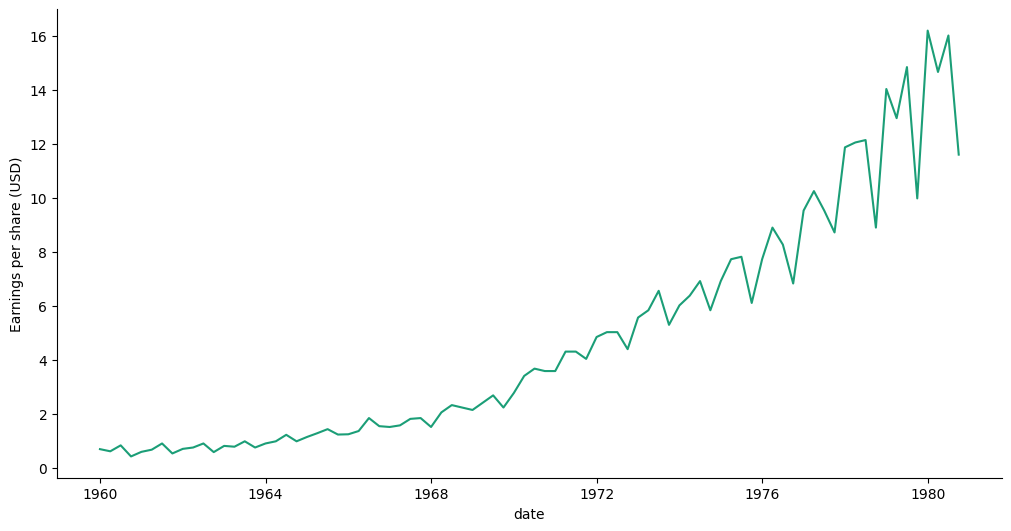

In [ ]:
# @title date vs data

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  ys = series['data']
  xs = np.asarray(xs, dtype='datetime64[s]')
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('Earnings per share (USD)')

In [ ]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [ ]:
df['year'] = pd.DatetimeIndex(df['date']).year
df

,date,data,year
0,1960-01-01,0.71,1960
1,1960-04-01,0.63,1960
2,1960-07-02,0.85,1960
3,1960-10-01,0.44,1960
4,1961-01-01,0.61,1961
...,...,...,...
79,1979-10-01,9.99,1979
80,1980-01-01,16.20,1980
81,1980-04-01,14.67,1980
82,1980-07-02,16.02,1980


##Components of a time series
We can further our understanding of time series by looking at their three components: a trend, a seasonal component, and residuals. In fact, all time series can be
decomposed into these three elements.

Visualizing the components of a time series is known as decomposition. Decomposition is defined as a statistical task that separates a time series into its different components. We can visualize each individual component, which will help us identify the
trend and seasonal pattern in the data, which is not always straightforward just by
looking at a dataset.

In [ ]:
advanced_decomposition = STL(df.data, period=4).fit()

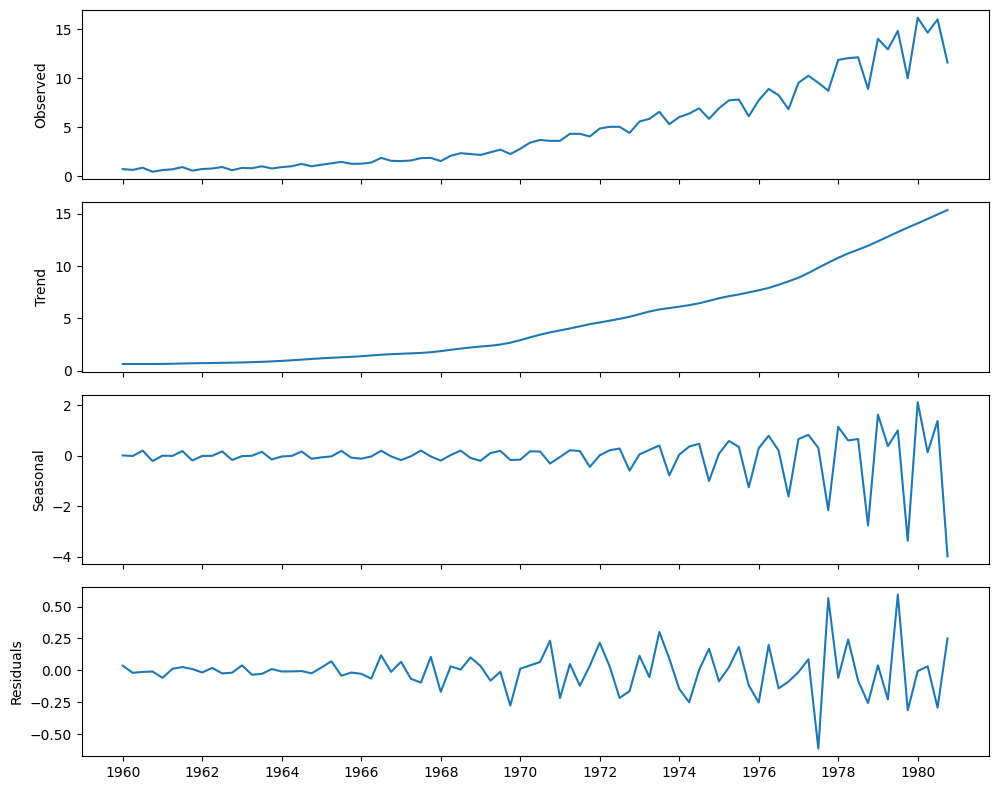

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(figsize=(10, 8), nrows=4, ncols=1, sharex=True)

ax1.plot(advanced_decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(advanced_decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(advanced_decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(advanced_decomposition.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# fig.autofmt_xdate()
plt.tight_layout()
plt.show()

##Time series decomposition
Time series decomposition is a process by which we separate a time series into its
components: trend, seasonality, and residuals.

The **trend** represents the slow-moving changes in a time series. It is responsible for
making the series gradually increase or decrease over time.

The **seasonality** component represents the seasonal pattern in the series. The cycles
occur repeatedly over a fixed period of time.

The **residuals** represent the behavior that cannot be explained by the trend and seasonality components. They correspond to random errors, also termed white noise.

##Time series forecasting
*Forecasting* is predicting the future using historical data and knowledge of future
events that might affect our forecasts. This definition is full of promises and, as data
scientists, we are often very eager to start forecasting by using our scientific knowledge
to showcase an incredible model with a near-perfect forecast accuracy. However, there
are important steps that must be covered before reaching the point of forecasting.

Let’s imagine that we wish to predict the quarterly earnings per
share (EPS) (lucros por ação) of Johnson & Johnson. Specifically, we will use the data from 1960 to the end of 1979 in order to predict the EPS for the four quarters of 1980. The forecasting period is illustrated by the gray zone in figure.

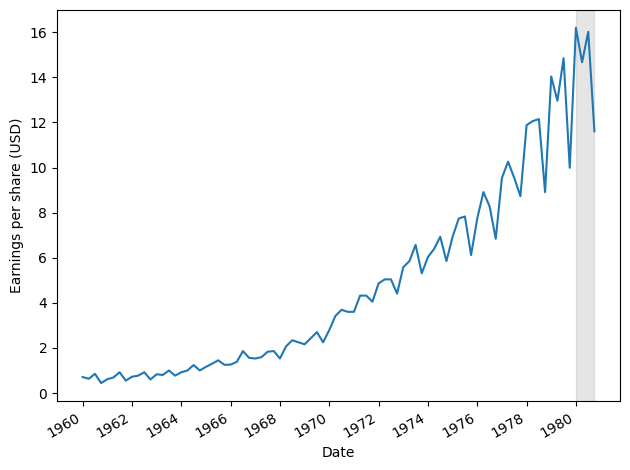

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['date'], df['data'])
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.tight_layout()

##Defining a baseline model
A baseline model is a trivial solution to our problem. It often uses heuristics, or simple
statistics, to generate predictions. The baseline model is the simplest solution you can
think of—it should not require any training, and the cost of implementation should
be very low.

In [ ]:
# Split to train/test
train = df[:-4]
test = df[-4:]

In [ ]:
test

,date,data,year
80,1980-01-01,16.20,1980
81,1980-04-01,14.67,1980
82,1980-07-02,16.02,1980
83,1980-10-01,11.61,1980


In [ ]:
# Predict historical mean
historical_mean = np.mean(train['data'])
historical_mean

4.308499987499999

In [ ]:
test.loc[:, 'pred_mean'] = historical_mean
test

<ipython-input-13-11c5128d9b37>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_mean'] = historical_mean


,date,data,year,pred_mean
80,1980-01-01,16.20,1980,4.3085
81,1980-04-01,14.67,1980,4.3085
82,1980-07-02,16.02,1980,4.3085
83,1980-10-01,11.61,1980,4.3085


###Error MetriC
Next, we need to define and calculate an error metric in order to evaluate the performance of our forecasts on the test set. In this case, we will use the **mean absolute percentage error** (MAPE). It is a measure of prediction accuracy for forecasting methods that is
easy to interpret and independent of the scale of our data. This means that whether we
are working with two-digit values or six-digit values, the MAPE will always be expressed as
a percentage.  Thus, the MAPE returns the percentage of how much the forecast values. deviate from the observed or actual values on average, whether the prediction was
higher or lower than the observed values. The MAPE is defined in equation below.
$$MAPE=\frac{1}{n} \sum^n_{1-n} \left| \frac{A_i - F_i}{A_i} \right|\times 100$$

$A_i$ is the actual value at point i in time, and $F_i$ is the forecast value at
point i in time; $n$ is simply the number of forecasts. In our case, because we are forecasting the four quarters of 1980, $n = 4$.

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
test['data']

80    16.20
81    14.67
82    16.02
83    11.61
Name: data, dtype: float64

In [ ]:
mape_hist_mean = mape(test['data'], test['pred_mean'])
mape_hist_mean

70.00752579965119

Running the function gives a MAPE of 70.00%. This means that our baseline deviates
by 70% on average from the observed quarterly EPS of Johnson & Johnson in 1980. Let’s visualize our forecasts to better understand our MAPE of 70%.

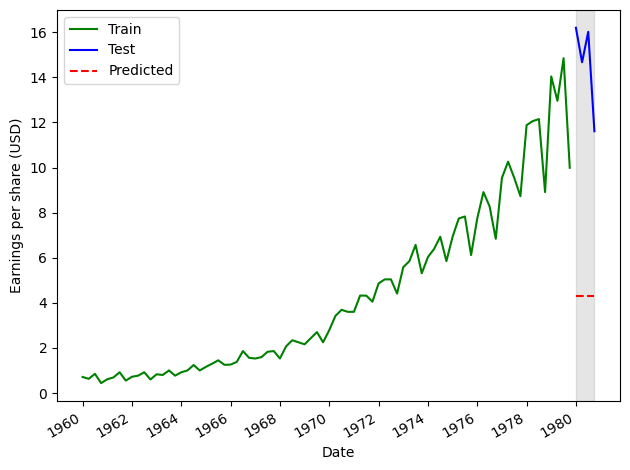

In [ ]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

Clearly, this baseline did not yield accurate predictions, since the Predicted line is very far from the Test line. Now we know that our forecasts are, on average, 70% below the actual EPS for each quarter in 1980. Whereas the EPS in 1980 was consistently above USD10, we predicted only USD4.31 for each quarter.

##Forecasting last year’s mean
The lesson learned from the previous baseline is that earlier values do not seem to be
predictive of future values in the long term because of the positive trend component
in our dataset. Earlier values seem to be too small to be representative of the new level
the EPS reaches toward the end of 1979 and onwards into 1980.

What if we use the mean of the last year in our training set to forecast the following
year? This means that we would compute the average EPS in 1979 and forecast it for
each quarter of 1980—the more recent values that have increased over time should
potentially be closer to what will be observed in 1980. For now, this is simply a hypothesis, so let’s implement this baseline and test it to see how it performs.

In [ ]:
train['data'][-4:]

76    14.04
77    12.96
78    14.85
79     9.99
Name: data, dtype: float64

In [ ]:
last_year_mean = np.mean(train['data'][-4:])
last_year_mean

12.96

In [ ]:
test.loc[:, 'pred__last_yr_mean'] = last_year_mean
test

<ipython-input-26-3792a0e0845f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred__last_yr_mean'] = last_year_mean


,date,data,year,pred_mean,pred__last_yr_mean
80,1980-01-01,16.20,1980,4.3085,12.96
81,1980-04-01,14.67,1980,4.3085,12.96
82,1980-07-02,16.02,1980,4.3085,12.96
83,1980-10-01,11.61,1980,4.3085,12.96


In [ ]:
mape_last_year_mean = mape(test['data'], test['pred__last_yr_mean'])
mape_last_year_mean

15.5963680725103

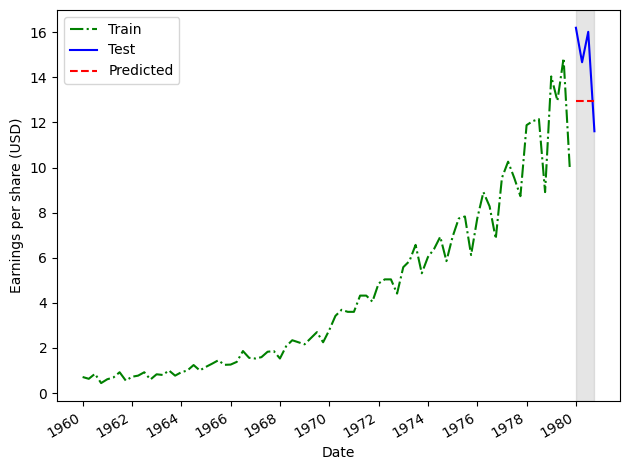

In [ ]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred__last_yr_mean'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

This new baseline is a clear improvement over the previous one, even though its
implementation is just as simple, as we decreased the MAPE from 70% to 15.6%. This
means that our forecasts deviate from the observed values by 15.6% on average. Using
the last year’s mean is a good step in the right direction. We want to get a MAPE as
close to 0% as possible, since that would translate into predictions that are closer to
the actual values in our forecast horizon.

##Predicting using the last known value
Previously we used the mean over different periods to develop a baseline model. So
far, the best baseline has been the mean of the last recorded year in our training set,
since it yielded the lowest MAPE. We learned from that baseline that future values
depend on past values, but not those too far back in time. Indeed, predicting the
mean EPS from 1960 to 1979 yielded worse forecasts than predicting the mean EPS
over 1979.

Therefore, we could suppose that using the last known value of the training set as a
baseline model will give us even better forecasts, which would translate to a MAPE
closer to 0%. Let’s test that hypothesis.

In [ ]:
last = train['data'].iloc[-1]
last

9.99

In [ ]:
test.loc[:, 'pred_last'] = last
test

<ipython-input-30-b51f481d993d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_last'] = last


,date,data,year,pred_mean,pred__last_yr_mean,pred_last
80,1980-01-01,16.20,1980,4.3085,12.96,9.99
81,1980-04-01,14.67,1980,4.3085,12.96,9.99
82,1980-07-02,16.02,1980,4.3085,12.96,9.99
83,1980-10-01,11.61,1980,4.3085,12.96,9.99


In [ ]:
mape_last = mape(test['data'], test['pred_last'])
mape_last

30.457277908606535

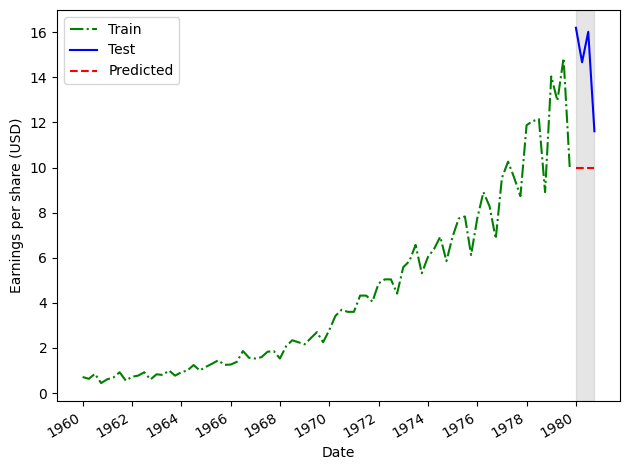

In [ ]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

It seems that our new hypothesis did not improve upon the last baseline that we built,
since we have a MAPE of 30.45%, whereas we achieved a MAPE of 15.60% using the mean EPS over 1979. Therefore, these new forecasts are farther from the observed values in 1980.

This can be explained by the fact that the EPS displays a cyclical behavior, where it
is high during the first three quarters and then falls at the last quarter. Using the last
known value does not take the seasonality into account, so we need to use another
naive forecasting technique to see if we can produce a better baseline.

##Naive seasonal forecast
We considered the trend component for the first two baselines in this chapter, but we
have not studied another important component from our dataset, which is the seasonal component shown in figure. There are clear cyclical patterns in our data,
and that is a piece of information that we could use to construct one last baseline: the
naive seasonal forecast.

The naive seasonal forecast takes the last observed cycle and repeats it into the future.
In our case, a full cycle occurs in four quarters, so we will take the EPS from the first
quarter of 1979 and predict that value for the first quarter of 1980. Then we’ll take the
EPS from the second quarter of 1979 and predict that value for the second quarter of 1980. This process will be repeated for the third and fourth quarters.

In [ ]:
test.loc[:, 'pred_last_season'] = train['data'][-4:].values
test

,date,data,year,pred_mean,pred__last_yr_mean,pred_last,pred_last_season
80,1980-01-01,16.20,1980,4.3085,12.96,9.99,14.04
81,1980-04-01,14.67,1980,4.3085,12.96,9.99,12.96
82,1980-07-02,16.02,1980,4.3085,12.96,9.99,14.85
83,1980-10-01,11.61,1980,4.3085,12.96,9.99,9.99


In [ ]:
mape_naive_seasonal = mape(test['data'], test['pred_last_season'])
mape_naive_seasonal

11.561658552433654

This gives us a MAPE of 11.56%, which is the lowest MAPE from all the baselines.

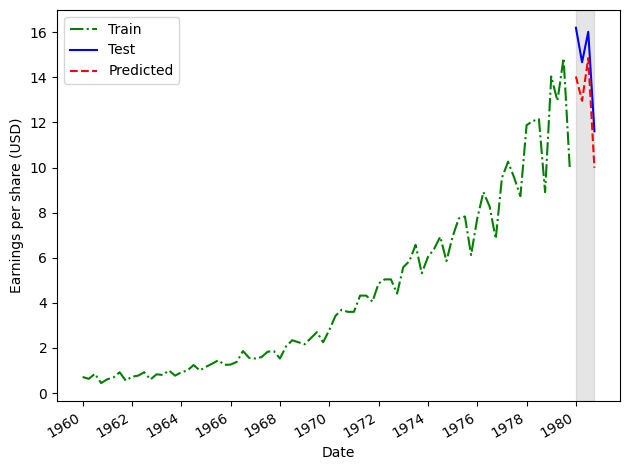

In [ ]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

As you can see, our naive seasonal forecast resulted in the lowest MAPE of all the baselines we built in this chapter. This means that seasonality has a significant impact on
future values, since repeating the last season into the future yields fairly accurate forecasts. Intuitively, this makes sense, because we can clearly observe a cyclical pattern
being repeated every year in figure.

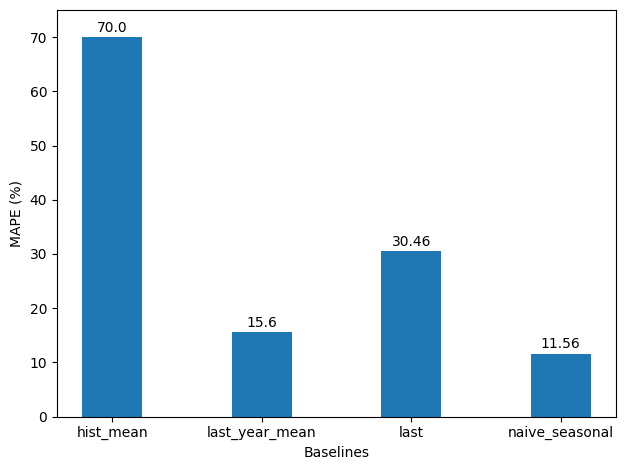

In [ ]:
fig, ax = plt.subplots()

x = ['hist_mean', 'last_year_mean', 'last', 'naive_seasonal']
y = [70.00, 15.60, 30.46, 11.56]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Baselines')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 75)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(value), ha='center')

plt.tight_layout()

##Forecasting non-stationary time series
Now we’ll use a model so we can forecast non-stationary time series. This component is the integration order, which is denoted by the variable d. This leads us to the **autoregressive integrated moving average** (ARIMA) model, or ARIMA(p,d,q). Using this model, we can take into account non-stationary time series and avoid the steps of modeling on differenced data and having to inverse transform the forecasts.

An autoregressive integrated moving average process is the combination of an autoregressive
process AR(p), integration I(d), and the moving average process MA(q).

In ARIMA(p,d,q) the order p determines how many lagged values of the series are included in the model, while the order q determines how many lagged error terms are included in the model. The order d is defined as the order of integration. Integration is simply the
reverse of differencing. The order of integration is thus equal to the number of times
a series has been differenced to become stationary. If we difference a series once and it becomes stationary, then d = 1. If a series is differenced twice to become stationary, then d = 2.

A time series that can be rendered stationary by applying differencing is said to be an
integrated series. In the presence of a non-stationary integrated time series, we can use
the ARIMA(p,d,q) model to produce forecasts.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

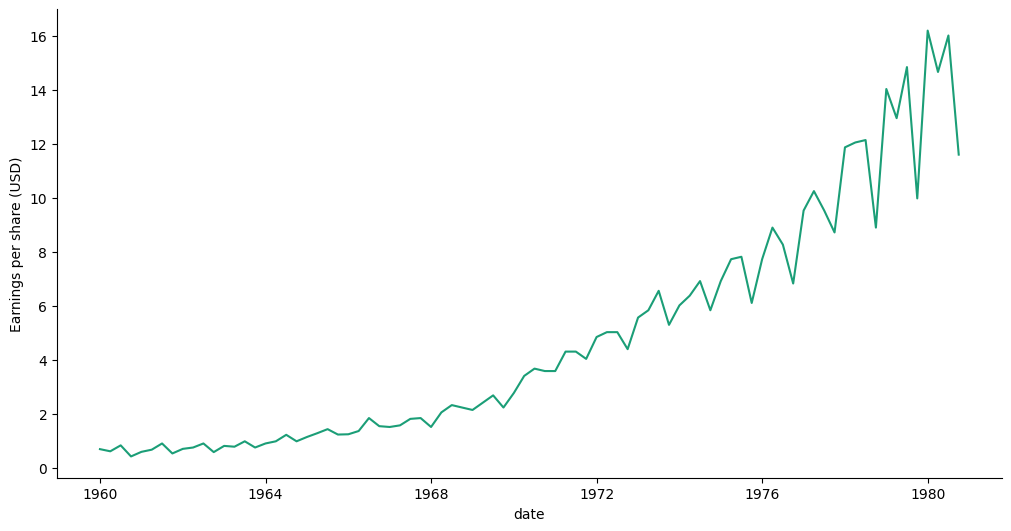

In [ ]:
# @title Non-stationary time series

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  ys = series['data']
  xs = np.asarray(xs, dtype='datetime64[s]')
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('Earnings per share (USD)')

Following our procedure, we must check if the data is stationary. Figure shows a
positive trend, as the quarterly EPS tends to increase over time. Nevertheless, we can
apply the augmented Dickey-Fuller (ADF) test to determine if it is stationary or not.
By now you should be very comfortable with these steps, so they will be accompanied
by minimal comments.

In [ ]:
ad_fuller_result = adfuller(df['data'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 2.7420165734574744
p-value: 1.0


This block of code returns an ADF statistic of 2.74 with a p-value of 1.0. Since the ADF
statistic is not a large negative number, and the p-value is larger than 0.05, we cannot
reject the null hypothesis, meaning that our series is not stationary.

We need to determine how many times the series must be differenced to become stationary. This will then set the order of integration d. We can apply a first-order differencing and test for stationarity

In [ ]:
eps_diff = np.diff(df['data'], n=1)
ad_fuller_result = adfuller(eps_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -0.40740976363804615
p-value: 0.9088542416911305


This results in an ADF statistic of –0.41 and a p-value of 0.9. Again, the ADF statistic is
not a large negative number, and the p-value is larger than 0.05. Therefore, we cannot
reject the null hypothesis and we must conclude that after a first-order differencing,
the series is not stationary.

In [ ]:
eps_diff2 = np.diff(eps_diff, n=1)
ad_fuller_result = adfuller(eps_diff2)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -3.585162874793155
p-value: 0.006051099869603682


This results in an ADF statistic of –3.59 and a p-value of 0.006. Now that we have a
p-value smaller than 0.05 and a large negative ADF statistic, we can reject the null
hypothesis and conclude that our series is stationary. It took two rounds of differencing to make our data stationary, which means that our order of integration is 2, so d = 2.

Before we move on to fitting different combinations of ARIMA(p,d,q) models, we
must separate our data into train and test sets. We will hold out the last year of data for
testing. This means that we will fit the model with data from 1960 to 1979 and predict
the quarterly EPS in 1980 to evaluate the quality of our model against the observed
values in 1980. In figure the testing period is the shaded area.

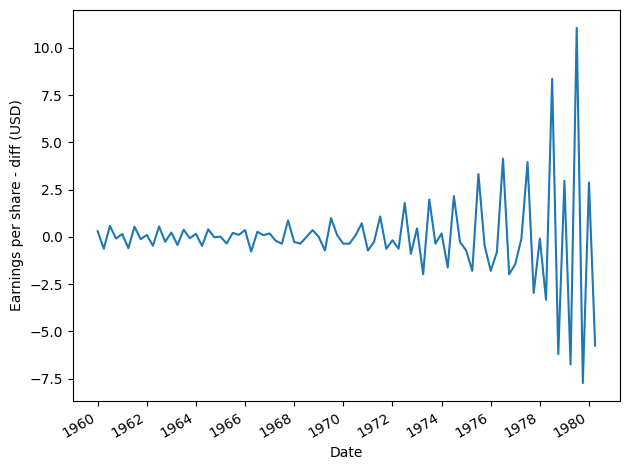

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['date'][2:], eps_diff2)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share - diff (USD)')

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

To fit the many ARIMA(p,d,q) models, we’ll define the optimize_ARIMA function. We’ll add the order of integration d as an input to the function. The remainder of the function stays the same, as we fit the different models and order them by ascending AIC in order to select the model with the lowest AIC. The optimize_ARIMA function is shown in the following listing.

In [ ]:
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:

    results = []
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue

        aic = model.aic
        results.append([order, aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

With the function in place, we can define a list of possible values for the orders p and
q. In this case, we’ll try the values 0, 1, 2, and 3 for both orders and generate the list of
unique (p,q) combinations.

In [ ]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
d = 2

order_list = list(product(ps, qs))
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

Note that we do not give a range of values for the parameter d because it has a very
specific definition: it is the number of times a series must be differenced to become
stationary. Hence, it must be set to a specific value, which in this case is 2.

Furthermore, d must be constant in order to compare models using the AIC. Varying d would change the likelihood function used in the calculation of the AIC value,
so comparing models using the AIC as a criterion would not be valid anymore.

We can now run the optimize_ARIMA function using the training set. The function
returns a DataFrame with the model that has the lowest AIC at the top.

In [ ]:
train = df['data'][:-4]

result_df = optimize_ARIMA(train, order_list, d)
result_df

<ipython-input-49-c639cc6afceb>:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: Conve

,"(p,q)",AIC
0,"(3, 3)",115.266637
1,"(3, 1)",115.624980
2,"(3, 2)",115.672007
3,"(3, 0)",154.430625
4,"(0, 3)",194.654716
5,"(0, 2)",209.274868
6,"(2, 3)",220.666965
7,"(1, 3)",228.267730
8,"(1, 2)",228.935782
9,"(2, 2)",229.974691


The returned DataFrame shows that a value of 3 for both p and q results in the lowest
AIC. Therefore, an ARIMA(3,2,3) model seems to be the most suitable for this situation. Now let’s assess the validity of the model by studying its residuals.

To do so, we’ll fit an ARIMA(3,2,3) model on the training set and display the
residuals’ diagnostics using the plot_diagnostics method.

In [ ]:
model = SARIMAX(train, order=(3,2,3), simple_differencing=False)
model_fit = model.fit(disp=False)

print(model_fit.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                   data   No. Observations:                   80
Model:               SARIMAX(3, 2, 3)   Log Likelihood                 -50.633
Date:                Mon, 13 May 2024   AIC                            115.267
Time:                        12:26:03   BIC                            131.764
Sample:                             0   HQIC                           121.871
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9994      0.037    -26.764      0.000      -1.073      -0.926
ar.L2         -0.9882      0.040    -25.002      0.000      -1.066      -0.911
ar.L3         -0.9758      0.026    -37.598      0.0

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


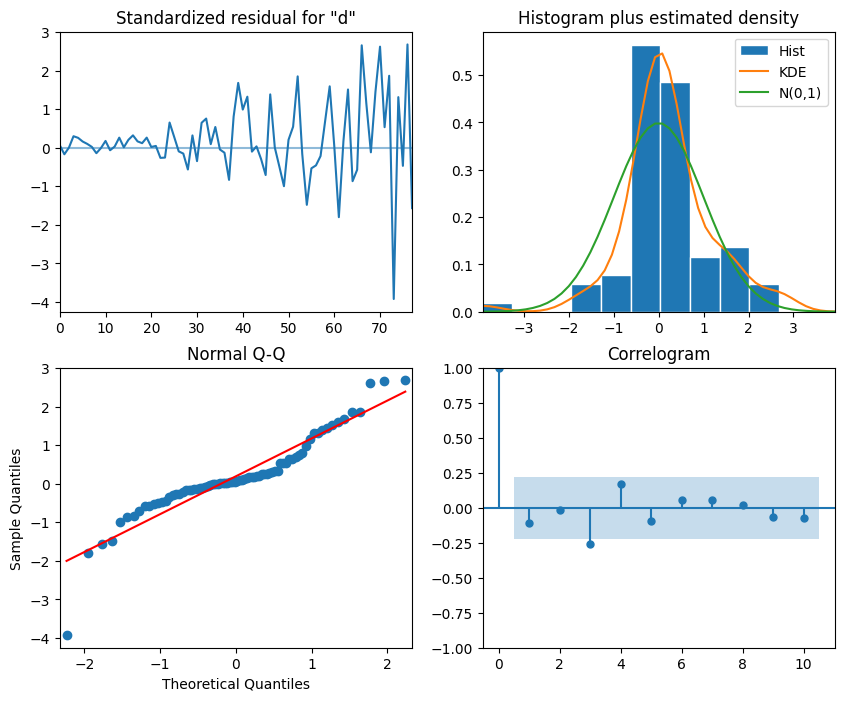

In [ ]:
model_fit.plot_diagnostics(figsize=(10,8));

In figure, the top-left plot shows the residuals over time. While there is no trend in
the residuals, the variance does not seem to be constant, which is a discrepancy in
comparison to white noise. At the top right is the distribution of the residuals. We can
see it is fairly close to a normal distribution. The Q-Q plot leads us to the same conclusion, as it displays a line that is fairly straight, meaning that the residual's distribution
is close to a normal distribution. Finally, by looking at the correlogram at the bottom
right, we can see that a coefficient seems to be significant at lag 3. However, since it is
not preceded by any significant autocorrelation coefficients, we can assume that this is
due to chance. Therefore, we can say that the correlogram shows no significant coefficients after lag 0, just like white noise.

Thus, from a qualitative standpoint, it seems that our residuals are close to white
noise, which is a good sign, as it means that the model’s errors are random.

The last step is to evaluate the residuals from a quantitative standpoint. We’ll thus
apply the Ljung-Box test to determine whether the residuals are correlated. We’ll
apply the test on the first 10 lags and study the p-values. If all p-values are greater than 0.05, we cannot reject the null hypothesis and we’ll conclude that the residuals are not
correlated, just like white noise.

In [ ]:
residuals = model_fit.resid
pvalue = acorr_ljungbox(residuals, np.arange(1, 11, 1))
pvalue

,lb_stat,lb_pvalue
1,1.652020,0.198684
2,1.654544,0.437241
3,7.276173,0.063597
4,9.231226,0.055573
5,9.853425,0.079497
6,10.097125,0.120621
7,10.346926,0.169751
8,10.379005,0.239426
9,10.721222,0.295303
10,11.159917,0.345196


Running the Ljung-Box test on the first 10 lags of the model’s residuals returns a list of p-values that are all larger than 0.05. Therefore, we do not reject the null hypothesis, and we conclude that the residuals are not correlated, just like white noise.

Our ARIMA(3,2,3) model has passed all the checks, and it can now be used for
forecasting. Remember that our test set is the last four data points, corresponding to the four quarterly EPS reported in 1980. As a benchmark for our model, we will use
the naive seasonal method. This means that we’ll take the EPS of the first quarter of
1979 and use it as a forecast for the EPS of the first quarter of 1980. Then the EPS of
the second quarter of 1979 will be used as a forecast for the EPS of the second quarter
of 1980, and so on. Remember that we need a benchmark, or a baseline model, when
modeling to determine whether the model we develop is better than a naive method.
The performance of a model must always be assessed relative to a baseline model.

In [ ]:
test = df.iloc[-4:]
test['naive_seasonal'] = df['data'].iloc[76:80].values
test

<ipython-input-55-23b7af8472fa>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_seasonal'] = df['data'].iloc[76:80].values


,date,data,year,naive_seasonal
80,1980-01-01,16.20,1980,14.04
81,1980-04-01,14.67,1980,12.96
82,1980-07-02,16.02,1980,14.85
83,1980-10-01,11.61,1980,9.99


With our baseline in place, we can now make forecasts using the ARIMA(3,2,3) model
and store the results in the ARIMA_pred column.

In [ ]:
ARIMA_pred = model_fit.get_prediction(80, 83).predicted_mean
test['ARIMA_pred'] = ARIMA_pred
test

<ipython-input-56-5db61a009341>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ARIMA_pred'] = ARIMA_pred


,date,data,year,naive_seasonal,ARIMA_pred
80,1980-01-01,16.20,1980,14.04,15.858693
81,1980-04-01,14.67,1980,12.96,14.381508
82,1980-07-02,16.02,1980,14.85,16.365509
83,1980-10-01,11.61,1980,9.99,11.680906


Let’s visualize our forecasts to see how close the predictions from each method are to
the observed values.

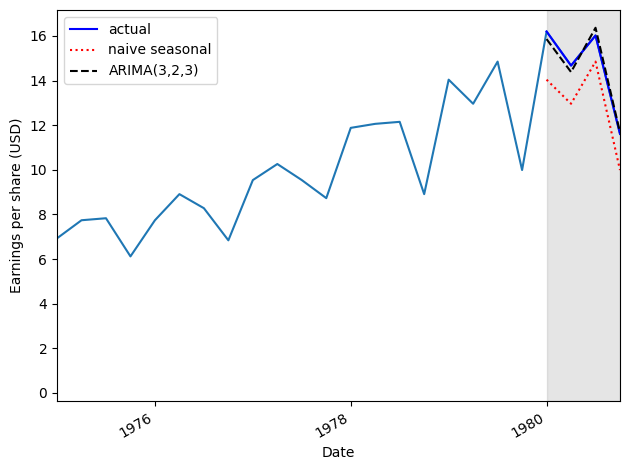

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.plot(test['data'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(3,2,3)')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
ax.set_xlim(60, 83)

fig.autofmt_xdate()
plt.tight_layout()

In figure we can see the naive seasonal forecast as a dotted line and the ARIMA(3,2,3)
forecasts as a dashed line. The ARIMA(3,2,3) model predicted the quarterly EPS with
a very small error.

We can quantify that error by measuring the mean absolute percentage error
(MAPE) and display the metric for each forecasting method in a bar plot.

In [ ]:
mape_naive_seasonal = mape(test['data'], test['naive_seasonal'])
mape_ARIMA = mape(test['data'], test['ARIMA_pred'])
print(mape_naive_seasonal, mape_ARIMA)

11.561658552433654 1.7102112169997594


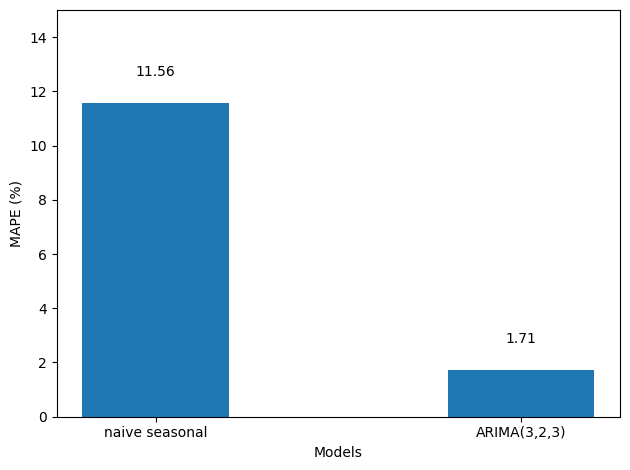

In [ ]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(3,2,3)']
y = [mape_naive_seasonal, mape_ARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()

In figure, you can see that the MAPE for the naive seasonal forecast is 11.56%,
while the MAPE for the ARIMA(3,2,3) model is 1.71%, which roughly one fifth of the
benchmark value. This means that our predictions are on average 1.71% off from the
actual values. The ARIMA(3,2,3) model is clearly a better model than the naive seasonal method

##Exercícios
1. Utilize o banco de dados 'Number of US Airline passengers from 1949 to 1960' para previsões simples e estatísticas. Comente os resultados.
1. Utilize a série  'the sales of widgets over 500 days' https://github.com/marcopeix/TimeSeriesForecastingInPython/blob/master/data/widget_sales.csv para previsões.
1. Utilize a cotação do dolar para tentativas de previsões. Comente os resultados.

##Referências
[1] [Time Series Forecasting Tutorial](https://www.datacamp.com/tutorial/tutorial-time-series-forecasting?utm_source=google&utm_medium=paid_search&utm_campaignid=19589720824&utm_adgroupid=157156375671&utm_device=m&utm_keyword=&utm_matchtype=&utm_network=g&utm_adpostion=&utm_creative=684592140413&utm_targetid=aud-517318242147:dsa-2218886984580&utm_loc_interest_ms=&utm_loc_physical_ms=9102164&utm_content=&utm_campaign=230119_1-sea~dsa~tofu_2-b2c_3-row-p2_4-prc_5-na_6-na_7-le_8-pdsh-go_9-na_10-na_11-na&gad_source=1&gclid=CjwKCAjwrcKxBhBMEiwAIVF8rJUDM6dKA9VpvU9MRxzlmqhySf-AHpm9-Z7Q8K8Ssz-EXIzZjP59cRoCNnMQAvD_BwE)

[2] https://medium.com/ensina-ai/princ%C3%ADpios-b%C3%A1sicos-para-criar-previs%C3%B5es-de-s%C3%A9ries-temporais-e58c451a25b

[3] https://medium.com/@yucavalcante/s%C3%A9ries-temporais-com-python-quando-e-como-utilizar-08e1a95d1943

[4] https://www.kaggle.com/code/kashnitsky/topic-9-part-1-time-series-analysis-in-python

[5] Marco Peixeiro. **Time Series Forecasting in Python**. Manning Publications Co. Shelter Island, NY. 2022.
